In [58]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [59]:
import random, os
import numpy as np

def seed_everything(seed: int = 69):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything()

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [60]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [61]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [62]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [63]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [64]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7036915..2.1308641].


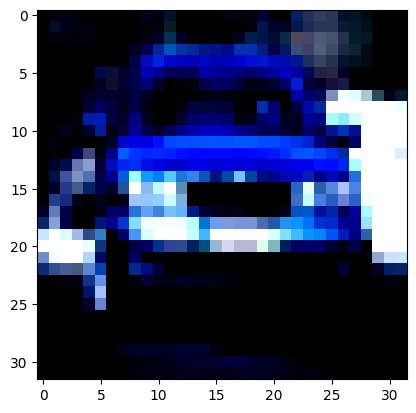

In [65]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [66]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [67]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [68]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [72]:
class Trainer:
    def __init__(self, model, config, transform=None):
        self.config = config
        self.transform = transform
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = model.to(self.device)
        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()
        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)
        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)
        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def plot_shit(self, train_losses, val_losses, train_accs, val_accs):
        epochs = range(1, self.config['num_epochs'] + 1)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.plot(epochs, val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over epochs')
        plt.legend()
        plt.grid(True)
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_accs, label='Train Acc')
        plt.plot(epochs, val_accs, label='Val Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.title('Accuracy over epochs')
        plt.legend()
        plt.grid(True)

        plt.show()

    def run(self):
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}, {train_loss=}, {val_loss=}, {val_acc=}')
        test_loss, test_acc = self.test_step()
        print(f'Test loss {test_loss}, test acc {test_acc}')
        self.plot_shit(train_losses, val_losses, train_accs, val_accs)

    def train_step(self):
        self.model.train()
        total_loss = 0.0
        correct = 0
        total_samples = 0
        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
        self.scheduler.step()
        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100
        return total_loss, train_acc

    def val_step(self):
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total_samples = 0
        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)
            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100
        return total_loss, val_acc

    def test_step(self):
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total_samples = 0
        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)
            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100
        return total_loss, test_acc

In [73]:
model = BasicCNN()
trainer = Trainer(model, config, transform=transform)

100%|██████████| 79/79 [00:02<00:00, 30.47it/s]


Epoch 1 / 10, train_loss=1.7259156802972666, val_loss=1.5238664436943923, val_acc=44.2


100%|██████████| 79/79 [00:02<00:00, 30.54it/s]


Epoch 2 / 10, train_loss=1.4512692998392513, val_loss=1.4076479771469212, val_acc=48.84


100%|██████████| 79/79 [00:02<00:00, 29.71it/s]


...

Epoch 9 / 10, train_loss=1.0376493944146763, val_loss=1.20033043245726, val_acc=57.410000000000004


100%|██████████| 79/79 [00:02<00:00, 30.58it/s]


Epoch 10 / 10, train_loss=1.0243079500457348, val_loss=1.1839272508138343, val_acc=57.76


100%|██████████| 79/79 [00:02<00:00, 31.45it/s]


Test loss 1.206128348278094, test acc 57.489999999999995


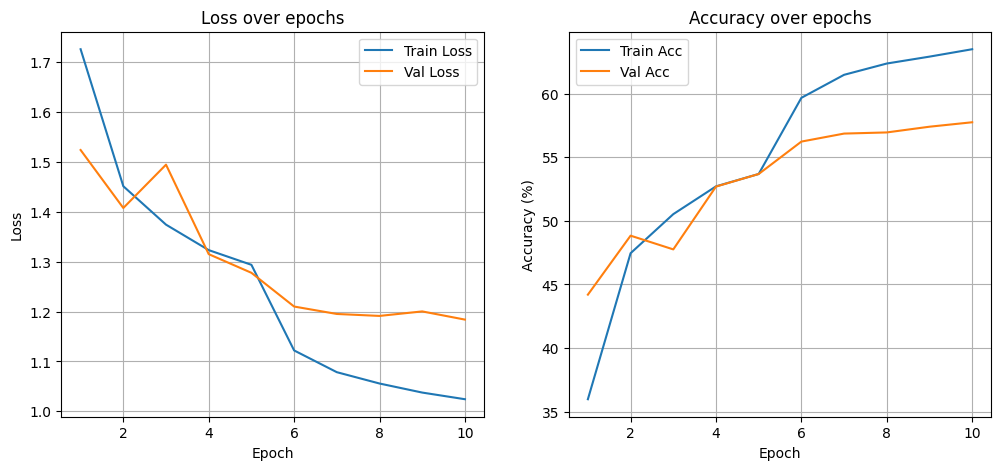

In [74]:
trainer.run()

# ResNet-18

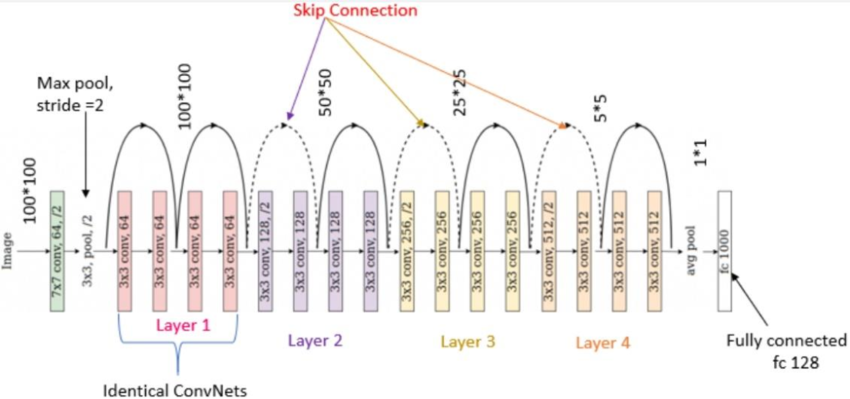

In [75]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.left = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.left(x)
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512, num_classes)
        
    def make_layer(self, out_channels, blocks, stride=1):
        strides = [stride] + [1]*(blocks-1)
        layers = []
        for stride in strides:
            layers.append(ResNetBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.max_pool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [ ]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

In [76]:
model = ResNet18()
trainer = Trainer(model, config, transform=transform)

100%|██████████| 79/79 [00:02<00:00, 27.21it/s]


Epoch 1 / 10, train_loss=1.8675047143960533, val_loss=1.5915430120274991, val_acc=45.31


100%|██████████| 79/79 [00:02<00:00, 27.06it/s]


Epoch 2 / 10, train_loss=1.3907070936867223, val_loss=1.291221460209617, val_acc=53.37


100%|██████████| 79/79 [00:02<00:00, 26.99it/s]


...

Epoch 9 / 10, train_loss=0.3350144560439899, val_loss=0.8488557776318321, val_acc=74.29


100%|██████████| 79/79 [00:03<00:00, 25.85it/s]


Epoch 10 / 10, train_loss=0.25188684844361325, val_loss=0.9474716563768024, val_acc=74.42999999999999


100%|██████████| 79/79 [00:03<00:00, 25.06it/s]


Test loss 0.9690811596339262, test acc 74.31


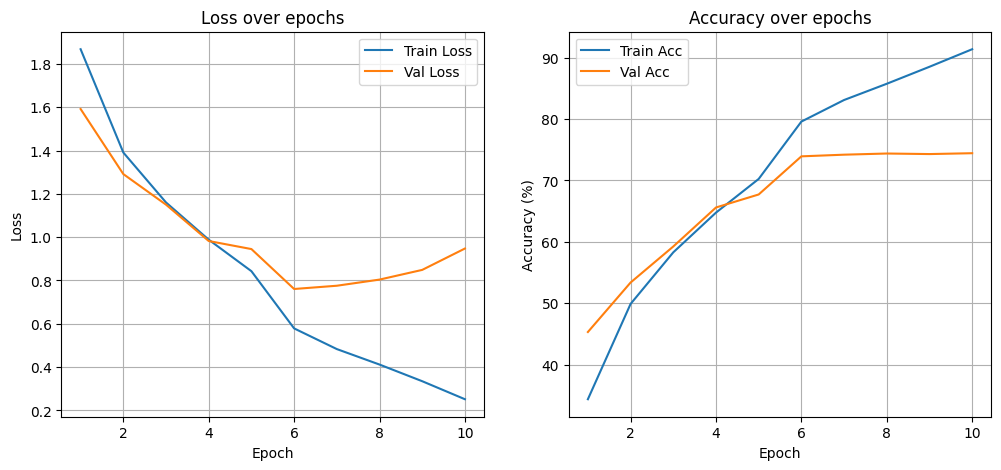

In [77]:
trainer.run()